# **Recursividade**

"mar calmo nunca fez bom marinheiro"


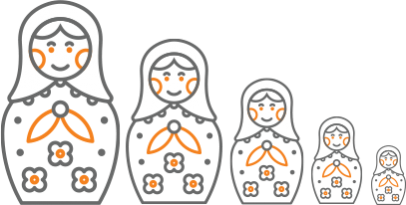

É legal para uma função chamar outra; também é legal para uma função chamar a si própria. Pode não ser óbvio porque isso é uma coisa boa, mas na verdade é uma das coisas mais mágicas que um programa pode fazer. Por exemplo, veja a seguinte função:

In [1]:
def contagem_regressiva(n):
  if n <= 0:
    print('Decolar!')
  else:
    print(n)
    contagem_regressiva(n-1)

Se n for 0 ou negativo, `Decolar!` é exibido, senão a saída é `n` e então a função é chamada (por si mesma) passando `n-1` como argumento.

In [2]:
contagem_regressiva(3)

3
2
1
Decolar!


## **Três Leis da Recursividade**

- Um algoritmo recursivo deve possuir um caso base (base case).
- Um algoritmo recursivo deve modificar o seu estado e se aproximar do caso base.
- Um algoritmo recursivo deve chamar a si mesmo, recursivamente.

## **Sequência de Fibonacci**

Definiremos agora uma sequência matemática muito famosa chamada Sequência de Fibonacci: 1,1,2,3,5,8,13,…. Nessa sequência, os dois termos iniciais são 0 e 1, e cada termo subsequente é igual à soma dos dois termos anteriores. O cálculo do n-ésimo termo da sequência de Fibonacci pode ser definido recursivamente da seguinte forma:

\begin{align*}
	F_n&= 
	\begin{cases}
		1 & \mbox{ se } n=0 \mbox{ ou } n=1,\\
		F_{n-1}+F_{n-2}& \mbox{ caso contrário }.
	\end{cases}
\end{align*}

A partir da definição acima, podemos implementar o cálculo do n-ésimo termo da sequência assim:

In [3]:
def fib(n):
  if n<=1: # Caso base: cálculo dos dois primeiros termos.
    return n
  else:
    return fib(n-1) + fib(n-2) # Cálculo do n-ésimo termo.

%time fib(35)

CPU times: user 4.1 s, sys: 28.9 ms, total: 4.13 s
Wall time: 4.18 s


9227465

Novamente, note a correspondência direta entre a definição e sua implementação. Entretanto, a implementação acima é ineficiente porque ela faz uma grande quantidade de trabalho repetido. Para ilustrar isso, veja a figura abaixo, ilustrando o cálculo de fib(5), que mostra as muitas chamadas repetidas da função `fib`, que, por questões de espaço, escrevemos simplesmente como `f`.

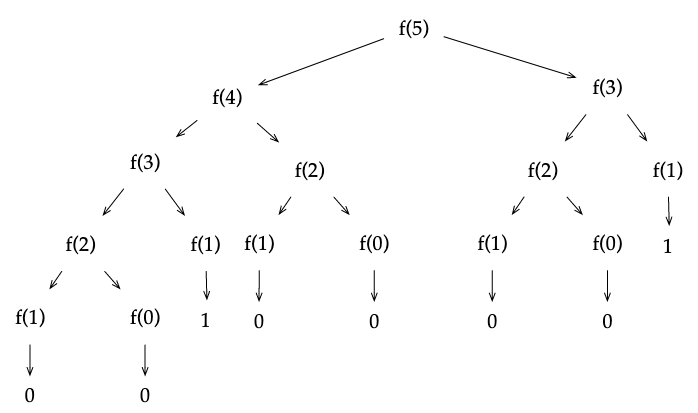

Existem formas mais eficientes de implementarmos a função `fib`, sem usar recursão, como a seguinte:

In [4]:
def fib(n):
  if n <= 1:
    return n
  fib_n_menos_2 = 0
  fib_n_menos_1 = 1
  for i in range(2, n):
    fib_n = fib_n_menos_1 + fib_n_menos_2
    fib_n_menos_2 = fib_n_menos_1
    fib_n_menos_1 = fib_n
  return fib_n_menos_1 + fib_n_menos_2

%time fib(35)

CPU times: user 15 µs, sys: 0 ns, total: 15 µs
Wall time: 21.2 µs


9227465

Pelo exemplo da função `fib` recursiva (e sua respectiva versão iterativa), você pode pensar que recursão não é um recurso tão vantajoso assim. Afinal, a versão iterativa não é muito mais complicada que a versão recursiva correspondente, e a versão iterativa é mais eficiente. Na prática, a versão iterativa de um algoritmo tende a ser mais eficiente que a versão recursiva. Entretanto, em alguns casos a versão iterativa é tão mais complicada que acaba sendo mais vantajoso usar a versão recursiva (por questões de legibilidade e facilidade de manutenção). Em outros casos (como o nosso próximo exemplo), a própria natureza recursiva do problema e a elevada complexidade computacional inerente a ele (uma solução iterativa não traria ganho significativo de desempenho) fazem com que recursão seja a melhor escolha.



## **Torres de Hanoi**

A lenda associada a esse problema é a seguinte: no templo de Brahma em Benares, debaixo do domo que marca o centro do mundo, existem 64 discos de ouro puro que os monges carregam, um de cada vez, para três agulhas de diamante. Eles fazem isso em obediência à ordenança imutável do deus Brahma, segundo a qual nenhum disco pode ser colocado em cima de um disco menor que ele.

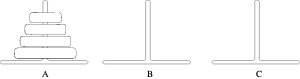

Segundo essa lenda, no começo do mundo, os 64 discos formavam uma torre (empilhados do maior para o menor) em uma das agulhas de diamante. O deus Brahma então ordenou aos monges que transferissem a torre de discos de uma agulha para outra, movendo um disco de cada vez e usando como "agulha auxiliar" a terceira agulha, e lhes disse que quando eles terminarem essa tarefa, chegará o fim do mundo.

In [5]:
def hanoi(n, origem, destino, aux):
  if n == 1: # Caso base: movendo um disco.
    print("Mova de {} para {}".format(origem, destino))
  else:
    hanoi(n-1,origem,aux,destino) # Movendo n-1 discos de 'origem' para 'aux'.
    hanoi(1,origem,destino,aux)   # Movendo um único disco de 'origem' para 'destino'.
    hanoi(n-1,aux,destino,origem) # Movendo os n-1 discos de 'aux' para 'destino'.

%time hanoi(4, 'A', 'C', 'B')

Mova de A para B
Mova de A para C
Mova de B para C
Mova de A para B
Mova de C para A
Mova de C para B
Mova de A para B
Mova de A para C
Mova de B para C
Mova de B para A
Mova de C para A
Mova de B para C
Mova de A para B
Mova de A para C
Mova de B para C
CPU times: user 4.92 ms, sys: 934 µs, total: 5.86 ms
Wall time: 6.54 ms


## **Calculando o Fatorial**




Considere-se o seguinte exemplo, que implementa a função fatorial. Recorde-se que para um número natural $n$ se tem:

\begin{align*}
	n!&= 
	\begin{cases}
		1 & \mbox{ se } n=0,\\
		n.(n-1)!& \mbox{ caso contrário }.
	\end{cases}
\end{align*}

Então o fatorial de 4 é calculado por:

4 x 3 x 2 x 1 = 24

O módulo math, que vimos anteriormente, já disponibiliza uma implementação.

In [6]:
from math import factorial as fact
print(fact(4))

24


Este fato não deve impedir-nos de programarmos a nossa própria definição. Isto é algo que faremos muitas vezes, não por razões de eficiência (a nossa definição será sempre menos eficiente que uma definição hiper-optimizada predefinida), mas por razões pedagógicas. 

Desta forma, com um laço *for* em *python*, o código ficaria assim:

In [7]:
def factorial(x):
  resultado = 1
  for i in range(1, x+1):
    resultado *= i
  return resultado

Utilizando recursão o código fica assim:

In [8]:
def factorial(x):
  if x == 0:
    return 1
  else:
    return x * factorial(x-1)

A implementação é muito semelhante à definição que vimos acima. Vamos analisar o código:
- O *if* é o caso base, sem ele a função entraria em loop. 
- O *else* é quem de fato faz toda mágica acontecer. 

É útil recorrer à ferramenta <a href="http://www.pythontutor.com">Python Tutor</a> para melhor compreender a avaliação de expressões envolvendo definições recursivas.



In [9]:
from IPython.display import IFrame

IFrame(src='https://pythontutor.com/iframe-embed.html#code=def+factorial(x%29%3A%0A++++if+x%3D%3D0%3A%0A++++++++return+1%0A++++else%3A+%0A++++++++return+x*factorial(x-1%29%0A++++++++%0Afactorial(4%29&origin=opt-frontend.js&cumulative=false&heapPrimitives=false&textReferences=false&py=3&rawInputLstJSON=%5B%5D&curInstr=0&codeDivWidth=350&codeDivHeight=400', 
       width=800, 
       height=500)

## **Calculando a Exponenciação**

Outro exemplo consiste na definição de exponenciação. Como sabemos, se $x\neq 0$, tem-se:

\begin{align*}
	x^n&= 
	\begin{cases}
		1 & \mbox{ se } n=0,\\
		x.x^{n-1}& \mbox{ caso contrário }.
	\end{cases}
\end{align*}

In [10]:
def exponencial(x,n):
  if n==0:
    return 1
  else:
    return x*exponencial(x,n-1)

exponencial(3,3)

27

In [11]:
IFrame(src='https://pythontutor.com/iframe-embed.html#code=def%20exponencial%28x,n%29%3A%0A%20%20if%20n%3D%3D0%3A%0A%20%20%20%20return%201%0A%20%20else%3A%0A%20%20%20%20return%20x*exponencial%28x,n-1%29%0A%0Aexponencial%283,3%29&codeDivHeight=400&codeDivWidth=350&cumulative=false&curInstr=0&heapPrimitives=nevernest&origin=opt-frontend.js&py=3&rawInputLstJSON=%5B%5D&textReferences=false', 
       width=800, 
       height=500)

## **Calculando o Máximo Divisor Comum**

Mais um exemplo, particularmente importante, é o denominado algoritmo de Euclides para o cálculo eficiente do máximo divisor comum entre dois números. A sua ideia básica está no fato de mdc(x,y) == mdc(y,x%y). O caso base é atingido quando algum dos valores é zero.

In [12]:
def mdc(x,y):
  if x==0 or y==0:
    return x+y
  else:
    return mdc(y,x%y)

mdc(10,20)

10

In [13]:
IFrame(src='https://pythontutor.com/iframe-embed.html#code=def%20mdc%28x,y%29%3A%0A%20%20if%20x%3D%3D0%20or%20y%3D%3D0%3A%0A%20%20%20%20return%20x%2By%0A%20%20else%3A%0A%20%20%20%20return%20mdc%28y,x%25y%29%0A%0Amdc%28234,1108%29&codeDivHeight=400&codeDivWidth=350&cumulative=false&curInstr=0&heapPrimitives=nevernest&origin=opt-frontend.js&py=3&rawInputLstJSON=%5B%5D&textReferences=false', 
       width=800, 
       height=500)

## **Recursão Sobre Listas**

É possível explorar a estrutura de outros tipos para construir recursões. É o caso das listas, que podemos destruir até ficarem vazias.

### **Comprimento**

Comecemos com um exemplo muito simples, o cálculo do comprimento de uma lista (obviamente sem usar `len`).

In [14]:
def compr(w):
  if w==[]:
    return 0
  else:
    return 1+compr(w[1:])

L = [4,5,6]

print(compr(L))

3


### **Média**

Queremos agora implementar uma função `media` que calcule o valor médio de uma lista de números. Claramente, será necessário calcular a soma dos elementos da lista. Para tal, definiremos uma função auxiliar, à custa da qual será muito simples calcular a média.

In [15]:
def somalista(w):
  if w==[]:
    return 0
  else:
    return w[0]+somalista(w[1:])

def media(w):
  if w==[]:
    print("erro, lista vazia")
  else:
    return somalista(w)/compr(w)

media([1,2,4])

2.3333333333333335

### **Lista dos naturais até n**

Implementar uma função `ate` que permita obter o efeito de `list(range(n))`.

In [16]:
def ate(n):
  if n==0:
    return []
  else: 
    return ate(n-1)+[n-1]
    
ate(4)

[0, 1, 2, 3]

### **Lista de factoriais**

Queremos, dada uma lista de valores naturais, calcular a lista dos seus factoriais.

In [17]:
def flista(w):
  if w==[]:
    return w
  else:
    return [factorial(w[0])]+flista(w[1:])

flista([5,7,10])

[120, 5040, 3628800]

# **Exercícios**

Nos três exercícios a seguir, faça uma versão recursiva e outra não recursiva.

1. Defina a função `soma_nat` que recebe como argumento um número natural `n` e devolve a soma de todos os números naturais até `n`. soma_nat(5) -> 15

2. Defina a função `quadrados` que recebe como argumento um número natural `n` e devolve a lista dos `n` primeiros quadrados perfeitos. Ex: quadrados(6) -> [1, 4, 9, 16, 25, 36]

3. Defina a função `inverte_lista` que recebe uma lista `w` e devolve a lista invertida. Ex: inverte_lista([1,2,3,4,5]) -> [5, 4, 3, 2, 1]



# **Desafio**

1. Uma *capicua* é um número natural que se lê de igual modo da esquerda para a direita ou da direita para a esquerda. O conceito análogo, para palavras, é o de *palíndromo*. Começamos por definir um predicado `palindromoQ` que determina se uma lista de valores dada é ou não um palíndromo. Definimos ainda uma outra função auxiliar que extrai, dado um número natural, a lista dos seus dígitos. Torna-se simples, de seguida, definir o predicado `capicuaQ`.

# **Glossário**

- A programação recursiva assenta num princípio básico da resolução de problemas: reduzir passo a passo cada problema a outro(s) mais simples, até chegar a casos básicos cuja solução seja imediata.
- A recursão tira partido, portanto, da estrutura indutiva dos valores do domínio das funções que se pretendem calcular.
- A concepção de algoritmos é uma tarefa criativa, que exige muita prática, mas que consiste essencialmente na boa compreensão do problema, na formulação mental da solução, e finalmente na respectiva codificação. 
- É importante procurar soluções não apenas corretas mas também eficientes para os problemas que nos são colocados.